# Exploratory Data Analysis and dataset building

Goal: tell whether a room is empty or has a person in it, using a smartphone as a
small sonar. The phone plays a short chirp, records the echo, and cross correlates
the echo with the chirp to get an echo profile: the reflection strength at each
distance. A person adds reflections, so the profile changes.

This notebook explores the data, cleans it, and builds the final dataset that the
model training notebook uses. Order:

1. The data sources.
2. The structure of the data.
3. Data quality: missing values and duplicates.
4. Cleaning and reshaping.
5. The collected rooms.
6. Building the final dataset (background subtraction and features).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})
BASE = os.path.join("..", "data", "external_zenodo", "raw")
OCC = ["empty", "person"]
REAL_ROOMS = ["room1", "room2", "room3"]
STYLE = {"empty": "-", "person": "--"}

def load_snaps(occ, room):
    f = pd.read_csv(os.path.join(BASE, occ, room, "Echo location.csv"), sep=";")
    d = pd.to_numeric(f.iloc[:, 0], errors="coerce").to_numpy()
    cols = [c for c in f.columns if c.startswith("Normalized CC")]
    snaps = [pd.to_numeric(f[c], errors="coerce").to_numpy() for c in cols]
    return d, [s for s in snaps if not np.isnan(s).all()]

dist, _ = load_snaps("empty", "room1")
BODY = (dist >= 34) & (dist <= 300)

## 1. The data sources

- Real data: the Indoor Acoustic Occupancy Dataset (Zenodo 18096214), a smartphone
  sonar recorded in 3 rooms, each empty and with one person.
- Own data: 8 extra rooms data collected in the same format, so we have enough data to train a model.

Together this is 11 rooms.

## 2. The structure of the data

The structure of the data is:
- There are 3 real rooms (room1, room2, room3).
- Each room is recorded in 2 scenarios, empty and with a person, so 2 recordings
  per room, and 6 recordings in total.
- Each recording is saved as one "Echo location" file.
- Inside one file there are 6 snapshots: the current echo reading plus the 5 taken
  just before it during the session.

So the structure is: room -> scenario (empty or person) -> recording -> 6 snapshots.

One Echo location file is a table of 1200 rows by 13 columns:

- Each row is one distance, from 34 cm to 459 cm, spaced about 0.35 cm apart.
- The columns are 1 distance column plus the 6 snapshots, each stored twice (a raw
  correlation and a normalized correlation), so 1 + 6 x 2 = 13.

Below are the first 3 rows of one file, with all 13 columns.

In [2]:
sample = pd.read_csv(os.path.join(BASE, "person", "room1", "Echo location.csv"), sep=";")
d = pd.to_numeric(sample.iloc[:, 0], errors="coerce")
print("shape:", sample.shape, "  distance:", round(d.min(),1), "to", round(d.max(),1), "cm")
pd.set_option("display.max_columns", None)
sample.head(3)

shape: (1200, 13)   distance: 34.0 to 458.6 cm


,Distance (cm),Crosscorrelation (a.u.),Normalized CC (a.u.),Crosscorrelation history 1 (a.u.),Normalized CC history 1 (a.u.),Crosscorrelation history 2 (a.u.),Normalized CC history 2 (a.u.),Crosscorrelation history 3 (a.u.),Normalized CC history 3 (a.u.),Crosscorrelation history 4 (a.u.),Normalized CC history 4 (a.u.),Crosscorrelation history 5 (a.u.),Normalized CC history 5 (a.u.)
0,34.000000,5.324869e-08,0.000062,1.788218e-07,0.000207,2.213871e-07,0.000256,4.920000e-07,0.000569,4.092880e-08,0.000047,1.749587e-07,0.000202
1,34.354167,4.967991e-08,0.000059,1.659506e-07,0.000196,2.418414e-07,0.000285,4.769600e-07,0.000563,4.478457e-08,0.000053,1.652778e-07,0.000195
2,34.708333,4.736199e-08,0.000057,1.453030e-07,0.000175,2.478582e-07,0.000299,4.536039e-07,0.000546,5.610575e-08,0.000068,1.507752e-07,0.000182


One echo profile, room2, empty and person. The person adds a rise around 1.5 to
2.5 m. This is the whole problem in one picture.

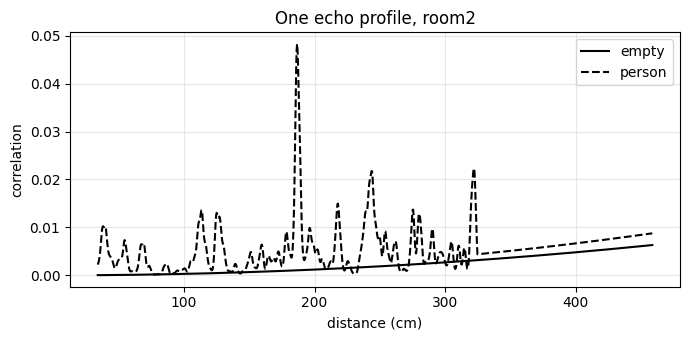

In [3]:
rows = []
for occ in OCC:
    f = pd.read_csv(os.path.join(BASE, occ, "room2", "Echo location.csv"), sep=";")
    dd = pd.to_numeric(f.iloc[:, 0], errors="coerce")
    cc = pd.to_numeric(f["Normalized CC (a.u.)"], errors="coerce")
    rows += [(occ, a, b) for a, b in zip(dd, cc)]
one = pd.DataFrame(rows, columns=["occupancy", "distance_cm", "norm_cc"])
fig, ax = plt.subplots(figsize=(7, 3.5))
for occ in OCC:
    s = one[one.occupancy == occ]
    ax.plot(s.distance_cm, s.norm_cc, color="black", linestyle=STYLE[occ], label=occ)
ax.set_xlabel("distance (cm)"); ax.set_ylabel("correlation"); ax.set_title("One echo profile, room2"); ax.legend()
plt.tight_layout(); plt.show()

## 3. Data quality: missing values and duplicates

I count the missing values in every column of every real recording. The raw
Crosscorrelation columns are badly and unevenly blank, so I drop them and keep the
Normalized Crosscorrelation columns, which are almost all complete. One normalized snapshot
(empty room1 history 1) is fully blank, so I drop it. There are no duplicate rows.

In [4]:
def short(c):
    c = c.replace(" (a.u.)", "").replace("Crosscorrelation", "raw").replace("Normalized CC", "norm")
    return c.replace(" history ", " h")
miss = {}
for occ in OCC:
    for room in REAL_ROOMS:
        f = pd.read_csv(os.path.join(BASE, occ, room, "Echo location.csv"), sep=";")
        miss[f"{occ}/{room}"] = {short(c): int(pd.to_numeric(f[c], errors="coerce").isna().sum()) for c in f.columns[1:]}
miss_df = pd.DataFrame(miss).T
print("missing values per column (0 = complete, 1200 = fully blank):")
miss_df

missing values per column (0 = complete, 1200 = fully blank):


,raw,norm,raw h1,norm h1,raw h2,norm h2,raw h3,norm h3,raw h4,norm h4,raw h5,norm h5
empty/room1,0,0,1200,1200,0,0,0,0,0,0,739,0
empty/room2,1197,0,362,0,0,0,0,0,0,0,0,0
empty/room3,1190,0,0,0,0,0,890,0,0,0,0,0
person/room1,670,0,0,0,663,0,0,0,0,0,0,0
person/room2,378,0,83,0,790,0,553,0,87,0,45,0
person/room3,0,0,412,0,0,0,0,0,287,0,29,0


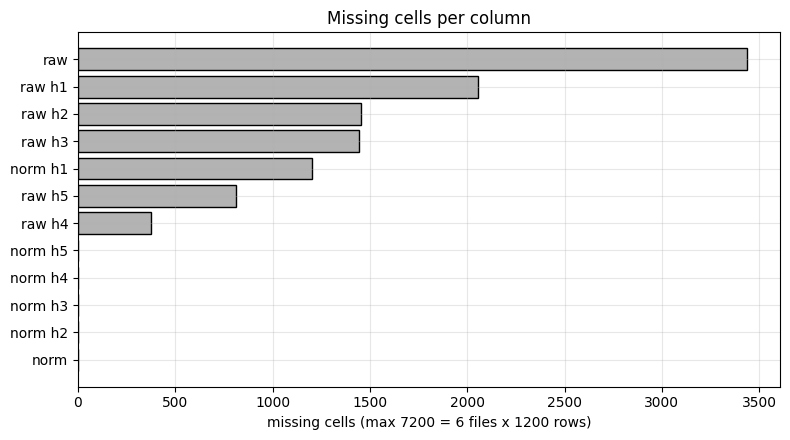

In [5]:
col_missing = miss_df.sum(axis=0).sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(range(len(col_missing)), col_missing.values, color="0.7", edgecolor="black")
ax.set_yticks(range(len(col_missing))); ax.set_yticklabels(col_missing.index)
ax.set_xlabel("missing cells (max 7200 = 6 files x 1200 rows)"); ax.set_title("Missing cells per column")
ax.grid(True, axis="x", alpha=0.3); plt.tight_layout(); plt.show()

## 4. Cleaning and reshaping

The 6 snapshots are stored as columns, which is not tidy. I melt them into rows so
one profile is one observation. Dropping the blank snapshot leaves 35 real
profiles.

In [6]:
records = []
for occ in OCC:
    for room in REAL_ROOMS:
        f = pd.read_csv(os.path.join(BASE, occ, room, "Echo location.csv"), sep=";")
        d0 = pd.to_numeric(f.iloc[:, 0], errors="coerce").to_numpy()
        for snap, col in enumerate([c for c in f.columns if c.startswith("Normalized CC")]):
            cc = pd.to_numeric(f[col], errors="coerce").to_numpy()
            for a, b in zip(d0, cc):
                records.append((occ, room, snap, a, b))
profiles = pd.DataFrame(records, columns=["occupancy", "room", "snapshot", "distance_cm", "norm_cc"]).dropna(subset=["norm_cc"]).reset_index(drop=True)
print("real profiles after cleaning:", profiles.groupby(["occupancy","room","snapshot"]).ngroups)
print("duplicate rows:", int(profiles.duplicated().sum()))
profiles.head()

real profiles after cleaning: 35
duplicate rows: 0


,occupancy,room,snapshot,distance_cm,norm_cc
0,empty,room1,0,34.000000,0.000244
1,empty,room1,0,34.354167,0.000260
2,empty,room1,0,34.708333,0.000255
3,empty,room1,0,35.062500,0.000230
4,empty,room1,0,35.416667,0.000195


The cleaned signal, room by room (current snapshot). A person raises the echo in
the 1 to 2.5 m range, strong in room2 and room3, weak in room1 where the empty
room already has a wall reflection near 3 m.

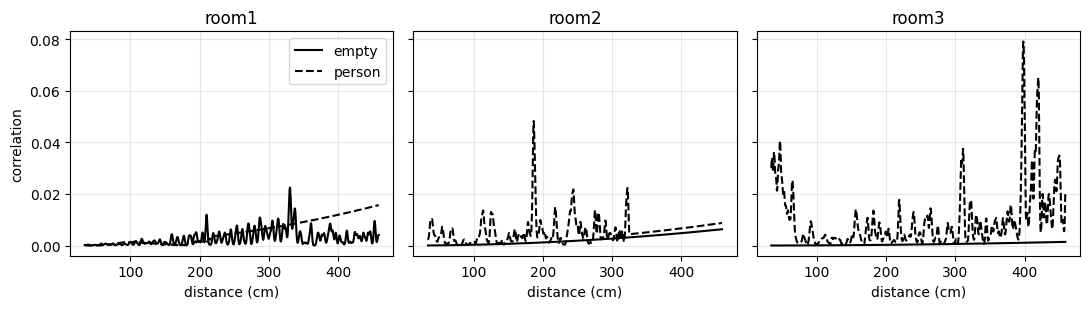

In [7]:
cur = profiles[profiles["snapshot"] == 0]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for ax, room in zip(axes, REAL_ROOMS):
    for occ in OCC:
        s = cur[(cur.room == room) & (cur.occupancy == occ)]
        ax.plot(s.distance_cm, s.norm_cc, color="black", linestyle=STYLE[occ], label=occ)
    ax.set_title(room); ax.set_xlabel("distance (cm)")
axes[0].set_ylabel("correlation"); axes[0].legend(); plt.tight_layout(); plt.show()

## 5. Own data

The real set is only 3 rooms, too small to train a model, so I collected 8 more
rooms in the same format. Each collected room has one fixed background, with several
empty and several person profiles inside it, so background subtraction works on it
just like a real room. Below are a few generated profiles.

own: 96 profiles across 8 rooms


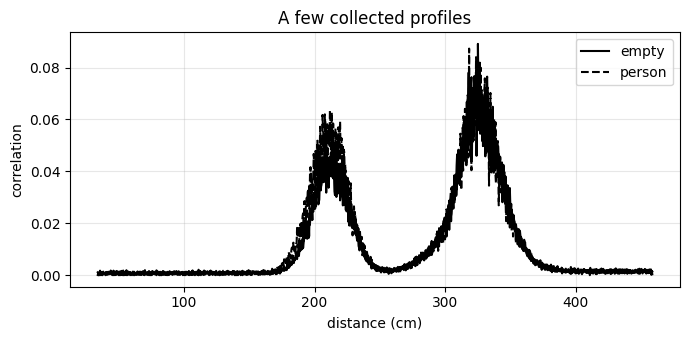

In [8]:
own = pd.read_csv(os.path.join("..", "data", "own_data", "profiles.csv"))
print("own:", own["sample"].nunique(), "profiles across", own.room.nunique(), "rooms")
fig, ax = plt.subplots(figsize=(7, 3.5))
for sid in [0, 1, 6, 7]:                     # 0,1 empty and 6,7 person of sim1
    s = own[own["sample"] == sid]
    ax.plot(s.distance_cm, s.norm_cc, color="black", linestyle=STYLE[s.occupancy.iloc[0]])
ax.plot([], [], color="black", linestyle="-", label="empty")
ax.plot([], [], color="black", linestyle="--", label="person")
ax.set_xlabel("distance (cm)"); ax.set_ylabel("correlation"); ax.set_title("A few collected profiles"); ax.legend()
plt.tight_layout(); plt.show()

## 6. Building the final dataset

For every room, real and own, I subtract the empty reference from each profile
(background subtraction) and compute two sets of features: the 7 raw features on the
profile, and the same 7 on the residual after subtraction. This gives the final
dataset, 131 profiles by 16 columns, saved to data/processed/final_dataset.csv.

In [9]:
def seven(curve, prefix):
    a = np.abs(curve); i = int(a[BODY].argmax())
    return {prefix+"peak": a[BODY][i], prefix+"peak_dist": dist[BODY][i],
            prefix+"near": a[(dist>=34)&(dist<=150)].mean(), prefix+"mid": a[(dist>150)&(dist<=300)].mean(),
            prefix+"far": a[(dist>300)&(dist<=459)].mean(), prefix+"mean": a.mean(), prefix+"std": a.std()}

def process_room(E, P, room):
    ref = np.mean(E, axis=0)
    noise = np.mean([np.mean(np.abs(E[i]-np.mean([E[j] for j in range(len(E)) if j!=i], axis=0))[BODY]) for i in range(len(E))])
    out = []
    for i, e in enumerate(E):
        ref_i = np.mean([E[j] for j in range(len(E)) if j!=i], axis=0)
        out.append({"room": room, "occupancy": "empty", **seven(e, "raw_"), **seven((e-ref_i)/noise, "res_")})
    for p in P:
        out.append({"room": room, "occupancy": "person", **seven(p, "raw_"), **seven((p-ref)/noise, "res_")})
    return out

rows = []
for room in REAL_ROOMS:
    _, E = load_snaps("empty", room); _, P = load_snaps("person", room)
    rows += process_room(E, P, room)
for room in sorted(own.room.unique(), key=lambda x: int(x[3:])):
    s = own[own.room == room]
    E = [s[(s.occupancy=="empty")&(s["sample"]==x)].sort_values("distance_cm").norm_cc.values for x in s[s.occupancy=="empty"]["sample"].unique()]
    P = [s[(s.occupancy=="person")&(s["sample"]==x)].sort_values("distance_cm").norm_cc.values for x in s[s.occupancy=="person"]["sample"].unique()]
    rows += process_room(E, P, room)

final = pd.DataFrame(rows)
final.to_csv(os.path.join("..", "data", "processed", "final_dataset.csv"), index=False)
print("final dataset:", final.shape[0], "profiles x", final.shape[1], "columns |",
      "rooms:", final.room.nunique(), "| classes:", dict(final.occupancy.value_counts()))
final.head()

final dataset: 131 profiles x 16 columns | rooms: 11 | classes: {'person': np.int64(66), 'empty': np.int64(65)}


,room,occupancy,raw_peak,raw_peak_dist,raw_near,raw_mid,raw_far,raw_mean,raw_std,res_peak,res_peak_dist,res_near,res_mid,res_far,res_mean,res_std
0,room1,empty,0.011962,210.020833,0.000714,0.003178,0.004334,0.002936,0.003018,5.119999,264.562500,0.172536,1.085454,2.910094,1.517122,2.154013
1,room1,empty,0.001189,210.020833,0.000134,0.000304,0.000585,0.000362,0.000446,6.459861,296.437500,0.252648,2.081540,4.979498,2.663547,2.951578
2,room1,empty,0.039387,296.437500,0.001269,0.008470,0.027058,0.013441,0.020571,15.942300,296.437500,0.409959,2.685552,10.213952,4.874159,8.848458
3,room1,empty,0.020304,264.562500,0.000257,0.003890,0.003408,0.002717,0.003526,5.666851,264.916667,0.192295,1.313423,3.591958,1.857634,2.541487
4,room1,empty,0.010192,172.479167,0.000489,0.003883,0.011096,0.005648,0.004857,3.977157,172.833333,0.156704,0.785920,3.171909,1.504703,1.978392


After subtraction, the near range energy clearly separates the two classes, which
is the signal the model will use.

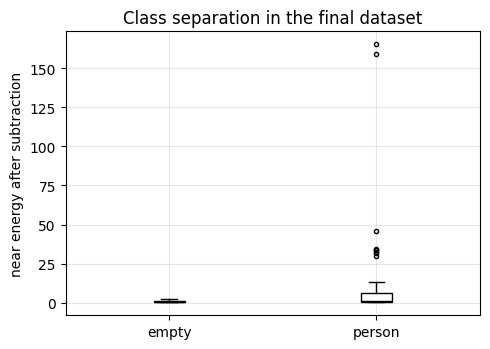

In [10]:
fig, ax = plt.subplots(figsize=(5, 3.6))
data = [final[final.occupancy == o]["res_near"] for o in OCC]
bp = ax.boxplot(data, patch_artist=True)
for b in bp["boxes"]: b.set(facecolor="white", edgecolor="black")
for part in ["whiskers","caps","medians"]:
    for ln in bp[part]: ln.set_color("black")
for fl in bp["fliers"]: fl.set(markeredgecolor="black", marker="o", markersize=3)
ax.set_xticks([1,2]); ax.set_xticklabels(OCC); ax.set_ylabel("near energy after subtraction")
ax.set_title("Class separation in the final dataset"); plt.tight_layout(); plt.show()